In [2]:
import os
import sys
import json
import warnings
import numpy as np
import sympy as sp
import pandas as pd
import proplot as pplt
from IPython.display import display,HTML
sys.path.insert(0,'..')
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
MODELSDIR = CONFIGS['filepaths']['models']
SRCONFIG  = CONFIGS['experiments']['sr']
SEEDS     = SRCONFIG['seeds']

In [4]:
VARDICT = {
    'rh':r'\widehat{\mathrm{RH}}',
    'thetae':r'\widehat{\theta}_{e}',
    'thetaestar':r'{\widehat{\theta}_{e}^{*}}',
    'lf':r'\mathrm{LF}',
    'shf':r'\mathrm{SHF}',
    'lhf':r'\mathrm{LHF}',}

SYMBOLS  = {k:sp.Symbol(k) for k in VARDICT}

FUNCDICT = {
    'cube':lambda x:x**3,
    'square':lambda x:x**2,
    'sqrt':sp.sqrt,
    'abs':sp.Abs,
    'neg':lambda x:-x,
    'exp':sp.exp,
    'log':sp.log,
    'sin':sp.sin,
    'cos':sp.cos}

LATEXREPLACE = {
    SYMBOLS['rh']:sp.Symbol(r'\widehat{\mathrm{RH}}'),
    SYMBOLS['thetae']:sp.Symbol(r'\widehat{\theta_e}'),
    SYMBOLS['thetaestar']:sp.Symbol(r'\widehat{\theta_e^*}'),
    SYMBOLS['lf']:sp.Symbol(r'\mathrm{LF}'),
    SYMBOLS['shf']:sp.Symbol(r'\mathrm{SHF}'),
    SYMBOLS['lhf']:sp.Symbol(r'\mathrm{LHF}')}

TERMORDER = {
    'rh':0,
    'thetae':1,
    'thetaestar':2,
    'lf':3,
    'shf':4,
    'lhf':5}

def _to_sympy_expr(eq):
    return sp.sympify(eq,locals={**SYMBOLS,**FUNCDICT})

def _round_numbers(expr,ndigits=4):
    return expr.xreplace({n: sp.Float(round(float(n),ndigits),ndigits) for n in expr.atoms(sp.Float)})

def _term_key(term):
    symbols = term.free_symbols
    if not symbols:
        return (99, str(term))
    names = sorted(s.name for s in symbols)
    return (min(TERMORDER.get(n,50) for n in names),str(term))

def _ordered_add_terms(expr):
    if isinstance(expr,sp.Add):
        terms = sp.Add.make_args(expr)
        return sp.Add(*sorted(terms,key=_term_key),evaluate=False)
    return expr

def _order_expr(expr):
    if expr.args:
        expr = expr.func(*[_order_expr(arg) for arg in expr.args],evaluate=False)
    if isinstance(expr,sp.Add):
        expr = _ordered_add_terms(expr)
    return expr

def _latex_expr(expr):
    SYMBOLNAMES = {SYMBOLS[k]: v for k, v in VARDICT.items()}
    latex = sp.latex(expr,symbol_names=SYMBOLNAMES,mul_symbol='dot')
    latex = latex.replace(r'\left', '').replace(r'\right', '')
    latex = ' '.join(latex.split())
    varslatex = list(VARDICT.values())
    for a in varslatex:
        for b in varslatex:
            latex = latex.replace(f'{a} \\cdot {b}',f'{a}({b})')
    return latex

def prettify(eq):
    try:
        expr = _to_sympy_expr(str(eq).strip())
        expr = sp.expand(expr)
        expr = sp.simplify(expr)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return '$'+_latex_expr(expr)+'$'
    except Exception:
        return str(eq).strip()
        
def load_equations(runname):
    seedframes = {}
    for seed in SEEDS:
        filepath = os.path.join(MODELSDIR, 'sr', f'{runname}_{seed}_equations.csv')
        df = pd.read_csv(filepath)
        df['seed'] = seed
        seedframes[seed] = df
    return seedframes
    
def equation_table(runname):
    seedframes = load_equations(runname)
    if not seedframes:
        return pd.DataFrame()
    rows = []
    for seed,df in seedframes.items():
        for _,row in df.iterrows():
            rows.append({'Seed':seed,'Complexity':int(row['complexity']),
                         'Loss':float(row['loss']),'Equation':prettify(str(row['equation']))})
    return pd.DataFrame(rows).sort_values(['Seed','Complexity']).reset_index(drop=True)

In [5]:
for runname in SRCONFIG['runs']:
    tbl = equation_table(runname)
    display(HTML(tbl.to_html(escape=False,index=False)))

Seed,Complexity,Loss,Equation
42,1,0.683615,$bl$
42,3,0.626950,$bl^{3}$
42,5,0.524241,$3.003 \cdot bl - 1.454$
42,6,0.506407,${3.405}^{bl} - 1.781$
42,7,0.495900,$bl^{3} + 0.8981 \cdot bl^{2} + 0.2689 \cdot bl - 0.4775$
42,9,0.495692,"$\max(-0.5981, bl^{3} + 0.8981 \cdot bl^{2} + 0.2689 \cdot bl - 0.4775)$"
42,11,0.495670,"$\max(0.045 \cdot bl, bl^{3} + 0.905 \cdot bl^{2} + 0.273 \cdot bl + 0.0275) - 0.5096$"
42,13,0.495565,"$0.0463 \cdot bl + \max(-0.0244, bl^{3} + 0.8641 \cdot bl^{2} + 0.2489 \cdot bl + 0.0239) - 0.4987$"
42,16,0.495565,"$0.0459 \cdot bl + \max(-0.0244, bl^{3} + 0.8641 \cdot bl^{2} + 0.2489 \cdot bl + 0.0239) - 0.4987$"
42,18,0.495563,"$0.0459 \cdot bl + \max(-0.0244, bl^{3} + 0.8641 \cdot bl^{2} + 0.2489 \cdot bl + 0.0239) - 0.4998$"


Seed,Complexity,Loss,Equation
42,1,0.998213,$0.0015$
42,2,0.679455,$\widehat{\mathrm{RH}}$
42,4,0.650312,$\widehat{\mathrm{RH}}^{3}$
42,6,0.631346,$1.337 \cdot \widehat{\mathrm{RH}}^{3}$
42,8,0.579281,$\mathrm{LF}(\mathrm{SHF}) + \widehat{\mathrm{RH}} - 1.4 \cdot \mathrm{SHF}$
42,10,0.547960,"$\mathrm{LF} \cdot \max(\mathrm{LF}, \mathrm{SHF}) + \widehat{\mathrm{RH}} - 1.73 \cdot \max(\mathrm{LF}, \mathrm{SHF})$"
42,11,0.500561,$4.296 \cdot \widehat{\theta}_{e} - 6.151 \cdot {\widehat{\theta}_{e}^{*}} - 4.693$
42,13,0.491193,"$\max(-0.4846, 4.706 \cdot \widehat{\theta}_{e} - 6.791 \cdot {\widehat{\theta}_{e}^{*}} - 5.249)$"
42,14,0.484834,$\widehat{\mathrm{RH}}(\widehat{\theta}_{e}) - 1.437 \cdot \widehat{\mathrm{RH}}({\widehat{\theta}_{e}^{*}}) - 1.081 \cdot \widehat{\mathrm{RH}} + 3.35 \cdot \widehat{\theta}_{e} - 4.813 \cdot {\widehat{\theta}_{e}^{*}} - 3.622$
42,16,0.465530,$\widehat{\mathrm{RH}}^{3} + 2.662 \cdot \widehat{\theta}_{e} - 3.91 \cdot {\widehat{\theta}_{e}^{*}} - 3.012$


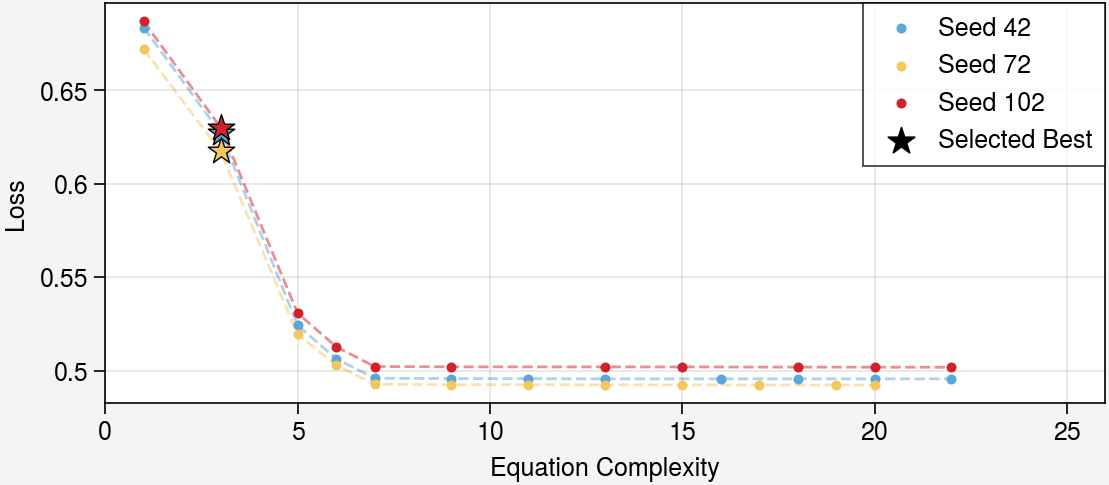

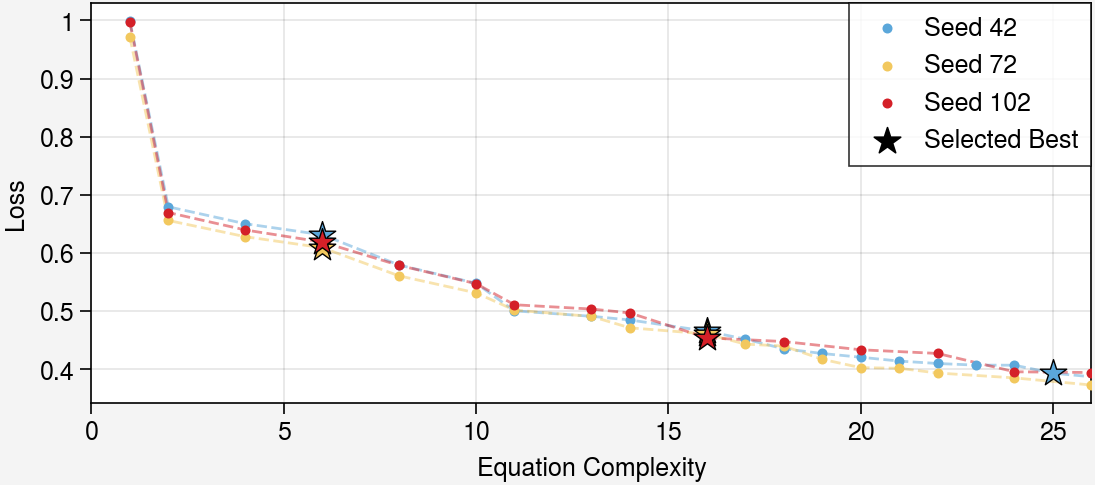

In [6]:
COLORS = ['#5BA7DA','#F2C85E','#D42028']

for runname in CONFIGS['experiments']['sr']['runs']:
    selected_cx = [spec['refcomplexity'] for spec in SRCONFIG['optimizedeqs'].values()
                   if spec['runfrom'] == runname]
    seedframes = load_equations(runname)
    fig,ax = pplt.subplots(refwidth=5,refheight=2)
    ax.format(xlabel='Equation Complexity',xlim=(0,26),ylabel='Loss')
    for i,(seed,df) in enumerate(sorted(seedframes.items())):
        df    = df.sort_values('complexity')
        color = COLORS[i%len(COLORS)]
        ax.plot(df['complexity'],df['loss'],color=color,alpha=0.5,linewidth=1,linestyle='--',zorder=1,label='')
        ax.scatter(df['complexity'],df['loss'],color=color,marker='.',zorder=3,label=f'Seed {seed}')
        for cx in selected_cx:
            row = df[df['complexity']==cx]
            if not row.empty:
                ax.scatter([row['complexity'].values[0]],[row['loss'].values[0]],
                    color=color,edgecolors='k',marker='*',markersize=100,linewidths=0.5,zorder=5)
    ax.scatter([],[],color='k',marker='*',markersize=100,label='Selected Best')
    ax.legend(loc='ur',ncols=1)
    pplt.show()
    # fig.save('../figs/fig_S2.jpg')

In [7]:
def seed_comparison(runname, complexity):
    seedframes = load_equations(runname)
    rows = []
    for seed, df in sorted(seedframes.items()):
        row = df[df['complexity'] == complexity]
        if row.empty:
            rows.append({'Seed': seed, 'Loss': '—', 'Equation': '—'})
        else:
            rows.append({'Seed': seed,
                         'Loss': f"{float(row.iloc[0]['loss']):.4f}",
                         'Equation': prettify(str(row.iloc[0]['equation']))})
    return pd.DataFrame(rows)

for eqname, eqspec in SRCONFIG.get('optimizedeqs', {}).items():
    runname = eqspec['runfrom']
    cx      = eqspec['refcomplexity']
    print(f'=== {eqname} | {runname} | complexity {cx} ===')
    display(HTML(seed_comparison(runname, cx).to_html(escape=False, index=False)))
    print()

=== sr_bl | sr_bl | complexity 3 ===


Seed,Loss,Equation
42,0.6270,$bl^{3}$
72,0.6173,$bl^{3}$
102,0.6301,$bl^{3}$



=== sr_lo | sr_gauss | complexity 6 ===


Seed,Loss,Equation
42,0.6313,$1.337 \cdot \widehat{\mathrm{RH}}^{3}$
72,0.6092,$1.343 \cdot \widehat{\mathrm{RH}}^{3}$
102,0.6189,$1.351 \cdot \widehat{\mathrm{RH}}^{3}$



=== sr_med | sr_gauss | complexity 16 ===


Seed,Loss,Equation
42,0.4655,$\widehat{\mathrm{RH}}^{3} + 2.662 \cdot \widehat{\theta}_{e} - 3.91 \cdot {\widehat{\theta}_{e}^{*}} - 3.012$
72,0.4608,$\widehat{\mathrm{RH}}^{3} + 2.573 \cdot \widehat{\theta}_{e} - 3.739 \cdot {\widehat{\theta}_{e}^{*}} - 2.902$
102,0.4542,"$\max(\widehat{\mathrm{RH}} + 0.3325, \widehat{\theta}_{e} - 1.426 \cdot {\widehat{\theta}_{e}^{*}})^{3} - 1.442$"



=== sr_hi | sr_gauss | complexity 25 ===


Seed,Loss,Equation
42,0.3934,$\widehat{\mathrm{RH}}^{3} - 0.8409 \cdot \mathrm{SHF} + 2.619 \cdot \widehat{\theta}_{e} - 3.284 \cdot {\widehat{\theta}_{e}^{*}} - 0.8409 \cdot |{\mathrm{LF} - \mathrm{SHF}}| - 2.006$
72,—,—
102,—,—


In [8]:
from IPython.display import Latex

def load_optimized(name):
    import pickle
    pklpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
    if not os.path.exists(pklpath):
        return None
    with open(pklpath,'rb') as f:
        registry = pickle.load(f)
    return registry.get(name)

def prettify_optimized(opt):
    '''Substitute optimized numeric constants into the form string and prettify.'''
    form      = opt['form']
    constants = opt['constants']
    # Replace constant names with their numeric values so sympy sees a pure expression
    ns = {**SYMBOLS, **FUNCDICT}
    ns.update({k: sp.Float(v) for k,v in constants.items()})
    try:
        expr = eval(form, {'__builtins__': {}}, ns)
        expr = sp.expand(expr)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return '$\\hat{P} = ' + _latex_expr(expr) + '$'
    except Exception as e:
        return f'{form}  [render error: {e}]'

rows = []
for name in SRCONFIG.get('optimizedeqs', {}):
    opt = load_optimized(name)
    if opt is None:
        print(f'{name}: not yet optimized')
        continue
    rows.append({
        'Name':      name,
        'Equation':  prettify_optimized(opt),
        'Train MSE': f"{opt['train_loss']:.4f}",
        'Valid MSE': f"{opt['valid_loss']:.4f}",
    })

display(HTML(pd.DataFrame(rows).to_html(escape=False,index=False)))

sr_bl: not yet optimized
sr_lo: not yet optimized
sr_med: not yet optimized
sr_hi: not yet optimized
